In [1]:
import pandas as pd, matplotlib, matplotlib.pyplot as plt
from af2genomics import *

In [2]:
df_ppi = read_ppi_reselect()
#n_total_ = 499321 # List from summary_source.out.bz2 filtered for human & unique interfaces
n_total_ = read_summary_source()['interaction_id'].nunique()
print(uf(n_total_), 'interactions for which a model was attempted')

310,581 raw records
310,572 after discarding non-dimers
211,081 after keeping uniprot_id-s in AF2 single fragment structures
211,079 after naive de-duplication of interaction_id
106,153 with pdockq > .23
24,524 with pdockq > .5
1,302,716 raw records
1,302,593 after discarding non-dimers
909,264 after keeping uniprot_id-s in AF2 single fragment structures
499,321 unique interaction_id-s
499,321 interactions for which a model was attempted


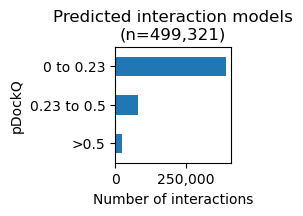

In [3]:
df_ppi['pdockq_bin'] = pd.cut(df_ppi['pdockq'], bins=[0.1, 0.23, 0.5, 1], labels=['0 to 0.23', '0.23 to 0.5', '>0.5'])
#sns.countplot(df_ppi, x='pdockq_bin', color='tab:blue')
df_counts_ = df_ppi['pdockq_bin'].value_counts()
df_counts_['0 to 0.23'] = n_total_ - df_counts_['0.23 to 0.5'] - df_counts_['>0.5']
df_counts_.to_frame().plot.barh(legend=None, figsize=(1.5, 1.5))
plt.gca().set_title(f'Predicted interaction models\n(n={uf(df_counts_.sum())})')
plt.gca().set_xlabel('Number of interactions')
plt.gca().set_ylabel('pDockQ')
plt.gca().xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))
plt.gca().invert_yaxis()
plt.savefig('pdockq_counts.svg', bbox_inches='tight', transparent=True)